### 7.11 Confounding by Indication

Examine the relationship between serious event rate and ROR to characterize potential confounding by indication — where drugs co-prescribed for the same severe disease may inflate ROR independently of a true pharmacodynamic interaction.

## Prerequisites

**Mixed dependencies — 7.11 self-contained, 7.12+ needs variables from notebook 02.**

This notebook covers Sections 7.11-7.13 of the original: confounding analysis, temporal stability, stable/unstable characteristics.

**⚠️ Superseded by corrections notebooks 07-09.** The temporal stability and characteristics analyses here use the old 2-criteria signal definition. The corrections notebooks use the FDR-consistent 3-criteria definition. Prefer 07-09 for the paper.

**Data required:**
- `../data/signals/FAERS_DDI_SIGNALS_FLAGGED.csv` — for 7.11 confounding analysis
- `../data/raw/FAERS_DDI_SIGNALS_HIGH_CONFIDENCE.csv` — for 7.12 HC subset
- `../data/raw/drug_atc_mapping.csv` — for 7.13 class analysis

**In-memory variables required** (from notebook 02, for 7.12+):
- `demo_all`, `drug_pairs_std_filtered`, `outcome_flags`

**To run 7.11 only:** Run the confounding cell — it's self-contained.

**To run 7.12+:** Run notebook 02 first, or use the setup cell below to load partial intermediates.

In [ ]:
# Setup cell — load intermediates saved by notebook 02 (only needed for 7.12+)
# If you're only running 7.11 (confounding analysis), skip this cell.
import pandas as pd
import numpy as np
import os

try:
    drug_pairs_std_filtered = pd.read_csv("../data/intermediate/FAERS_DRUG_PAIRS_RXNORM.csv")
    print(f"Loaded drug_pairs_std_filtered: {len(drug_pairs_std_filtered):,} rows")

    # outcome_flags and demo_all — saved by notebook 02
    outcome_flags_path = "../data/intermediate/FAERS_OUTCOME_FLAGS.csv"
    demo_all_path = "../data/intermediate/FAERS_DEMO_ALL.csv"

    if os.path.exists(outcome_flags_path):
        outcome_flags = pd.read_csv(outcome_flags_path)
        print(f"Loaded outcome_flags (full): {len(outcome_flags):,} rows")
    else:
        outcome_flags = drug_pairs_std_filtered[['PRIMARYID', 'SERIOUS']].drop_duplicates().reset_index(drop=True)
        print(f"⚠️  FAERS_OUTCOME_FLAGS.csv not found. Using exposed-only reconstruction.")

    if os.path.exists(demo_all_path):
        demo_all = pd.read_csv(demo_all_path)
        print(f"Loaded demo_all: {len(demo_all):,} rows")
    else:
        print(f"⚠️  FAERS_DEMO_ALL.csv not found. Run notebook 02 first to create it.")
        demo_all = None
except FileNotFoundError as e:
    print(f"Intermediate files not found: {e}")
    print("Run notebook 02_ddi_data_preparation.ipynb first.")

In [85]:
# =============================================================================
# QUANTIFY CONFOUNDING BY INDICATION
# =============================================================================
# Show the relationship between serious rate and ROR to demonstrate
# why extreme ROR values are likely confounded

signals = pd.read_csv("../data/signals/FAERS_DDI_SIGNALS_FLAGGED.csv")

print("CONFOUNDING BY INDICATION — EVIDENCE")
print("=" * 60)

# Signals binned by serious rate
bins = [(50, 70), (70, 80), (80, 90), (90, 95), (95, 100)]
for low, high in bins:
    subset = signals[(signals['PCT_SERIOUS'] >= low) & (signals['PCT_SERIOUS'] < high)]
    if len(subset) > 0:
        print(f"  Serious rate {low}-{high}%: {len(subset):,} signals, median ROR = {subset['ROR'].median():.1f}")

print(f"\nCorrelation between serious rate and ROR: {signals['PCT_SERIOUS'].corr(signals['ROR']):.3f}")
print("\nInterpretation: Higher correlation suggests ROR is partly driven by")
print("disease severity (confounding) rather than purely drug interactions.")

CONFOUNDING BY INDICATION — EVIDENCE
  Serious rate 50-70%: 2,217 signals, median ROR = 2.1
  Serious rate 70-80%: 11,491 signals, median ROR = 2.9
  Serious rate 80-90%: 13,161 signals, median ROR = 5.4
  Serious rate 90-95%: 8,319 signals, median ROR = 11.6
  Serious rate 95-100%: 3,240 signals, median ROR = 27.1

Correlation between serious rate and ROR: 0.588

Interpretation: Higher correlation suggests ROR is partly driven by
disease severity (confounding) rather than purely drug interactions.


### 7.12 Temporal Stability Analysis

Validate that DDI signals are consistent across time rather than driven by reporting artifacts in a single quarter. The dataset is split into two halves:

- **H1:** Q1–Q2 2025
- **H2:** Q3–Q4 2025

ROR is recalculated independently for each half using the same global denominator and RxNorm-standardized drug pairs as the main pipeline. Signal definition matches the main pipeline: ROR > 2.0 AND CI lower bound > 1.0, with N ≥ 10.

This broader signal definition (no quality flags) is intentional — we want to test temporal consistency across ALL signals, not just the quality-filtered HC subset.

In [86]:
# ============================================================
# TEMPORAL STABILITY ANALYSIS: Q1-Q2 vs Q3-Q4 (CORRECTED)
# Uses drug_pairs_std_filtered (RxNorm standardized) to match main pipeline
# ============================================================
import numpy as np
from scipy import stats

print("TEMPORAL STABILITY ANALYSIS (CORRECTED)")
print("=" * 60)

# --- STEP 1: Split patients by half-year ---
h1_quarters = ['Q1_2025', 'Q2_2025']
h2_quarters = ['Q3_2025', 'Q4_2025']

h1_patients = set(demo_all[demo_all['QUARTER'].isin(h1_quarters)]['PRIMARYID'])
h2_patients = set(demo_all[demo_all['QUARTER'].isin(h2_quarters)]['PRIMARYID'])

print(f"H1 (Q1-Q2) patients: {len(h1_patients):,}")
print(f"H2 (Q3-Q4) patients: {len(h2_patients):,}")

# Split STANDARDIZED drug pairs by half
pairs_h1 = drug_pairs_std_filtered[drug_pairs_std_filtered['PRIMARYID'].isin(h1_patients)].copy()
pairs_h2 = drug_pairs_std_filtered[drug_pairs_std_filtered['PRIMARYID'].isin(h2_patients)].copy()

print(f"\nH1 pair-patient observations: {len(pairs_h1):,}")
print(f"H2 pair-patient observations: {len(pairs_h2):,}")
print(f"Using RxNorm-standardized pairs (matches main pipeline)")

# --- STEP 2: Use same denominator approach as main pipeline ---
# Main pipeline uses total patients from outcome_flags
total_patients = len(outcome_flags)
total_serious = outcome_flags['SERIOUS'].sum()
total_non_serious = total_patients - total_serious

print(f"\nGlobal denominator (same as main pipeline):")
print(f"  Total patients: {total_patients:,}")
print(f"  Serious: {total_serious:,}")
print(f"  Non-serious: {total_non_serious:,}")

def calculate_ror_temporal(pairs_df, total_serious, total_non_serious, min_n=10):
    """Calculate ROR matching main pipeline methodology."""
    pair_stats = pairs_df.groupby('PAIR').agg(
        N_EXPOSED=('PRIMARYID', 'count'),
        A_SERIOUS=('SERIOUS', 'sum')
    ).reset_index()

    pair_stats['B_NONSERIOUS'] = pair_stats['N_EXPOSED'] - pair_stats['A_SERIOUS']

    # Same denominator as main pipeline
    pair_stats['C'] = total_serious - pair_stats['A_SERIOUS']
    pair_stats['D'] = total_non_serious - pair_stats['B_NONSERIOUS']

    # Continuity correction (same as main pipeline)
    a = pair_stats['A_SERIOUS'].clip(lower=0.5)
    b = pair_stats['B_NONSERIOUS'].clip(lower=0.5)
    c = pair_stats['C'].clip(lower=0.5)
    d = pair_stats['D'].clip(lower=0.5)

    pair_stats['ROR'] = (a * d) / (b * c)

    # 95% CI
    log_ror = np.log(pair_stats['ROR'])
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    pair_stats['CI_LOWER'] = np.exp(log_ror - 1.96 * se)
    pair_stats['CI_UPPER'] = np.exp(log_ror + 1.96 * se)

    # Filter
    pair_stats = pair_stats[pair_stats['N_EXPOSED'] >= min_n].copy()
    pair_stats = pair_stats.dropna(subset=['ROR'])
    pair_stats['SIGNAL'] = (pair_stats['ROR'] > 2.0) & (pair_stats['CI_LOWER'] > 1.0)

    return pair_stats

print("\nCalculating ROR for H1 (Q1-Q2)...")
ror_h1 = calculate_ror_temporal(pairs_h1, total_serious, total_non_serious, min_n=10)
print(f"  Pairs with 10+ obs: {len(ror_h1):,}")
print(f"  Signals (ROR>2, CI_lower>1): {ror_h1['SIGNAL'].sum():,}")

print("\nCalculating ROR for H2 (Q3-Q4)...")
ror_h2 = calculate_ror_temporal(pairs_h2, total_serious, total_non_serious, min_n=10)
print(f"  Pairs with 10+ obs: {len(ror_h2):,}")
print(f"  Signals (ROR>2, CI_lower>1): {ror_h2['SIGNAL'].sum():,}")

# --- STEP 3: Merge and compare ---
comparison = ror_h1[['PAIR', 'ROR', 'N_EXPOSED', 'SIGNAL']].merge(
    ror_h2[['PAIR', 'ROR', 'N_EXPOSED', 'SIGNAL']],
    on='PAIR', suffixes=('_H1', '_H2')
)
print(f"\nPairs present in BOTH halves: {len(comparison):,}")

# Correlation
r, p = stats.pearsonr(comparison['ROR_H1'], comparison['ROR_H2'])
rho, p_spearman = stats.spearmanr(comparison['ROR_H1'], comparison['ROR_H2'])
print(f"\nROR Correlation:")
print(f"  Pearson r = {r:.4f} (p = {p:.2e})")
print(f"  Spearman rho = {rho:.4f} (p = {p_spearman:.2e})")

# Signal agreement
both_signal = (comparison['SIGNAL_H1'] & comparison['SIGNAL_H2']).sum()
h1_only = (comparison['SIGNAL_H1'] & ~comparison['SIGNAL_H2']).sum()
h2_only = (~comparison['SIGNAL_H1'] & comparison['SIGNAL_H2']).sum()
neither = (~comparison['SIGNAL_H1'] & ~comparison['SIGNAL_H2']).sum()

print(f"\nSignal Agreement:")
print(f"  Signal in BOTH halves: {both_signal:,}")
print(f"  Signal in H1 only: {h1_only:,}")
print(f"  Signal in H2 only: {h2_only:,}")
print(f"  Signal in neither: {neither:,}")
print(f"  Agreement rate: {(both_signal + neither) / len(comparison) * 100:.1f}%")

# Top signal overlap
top200_h1 = set(ror_h1.nlargest(200, 'ROR')['PAIR'])
top200_h2 = set(ror_h2.nlargest(200, 'ROR')['PAIR'])
overlap_200 = top200_h1 & top200_h2
print(f"\nTop 200 Signal Overlap:")
print(f"  Shared in both top 200: {len(overlap_200)} ({100*len(overlap_200)/200:.1f}%)")

# Verify consistency with main pipeline
main_hc = pd.read_csv("../data/signals/FAERS_DDI_SIGNALS_HIGH_CONFIDENCE.csv")
main_pairs = set(main_hc['PAIR'])
h1_pairs = set(ror_h1['PAIR'])
h2_pairs = set(ror_h2['PAIR'])
print(f"\nConsistency check:")
print(f"  Main HC signals: {len(main_pairs):,}")
print(f"  Main HC signals found in H1 data: {len(main_pairs & h1_pairs):,}")
print(f"  Main HC signals found in H2 data: {len(main_pairs & h2_pairs):,}")
print(f"  Main HC signals found in BOTH: {len(main_pairs & h1_pairs & h2_pairs):,}")

comparison.to_csv("../results/FAERS_TEMPORAL_STABILITY.csv", index=False)
print("\nSaved: FAERS_TEMPORAL_STABILITY.csv")

TEMPORAL STABILITY ANALYSIS (CORRECTED)
H1 (Q1-Q2) patients: 671,817
H2 (Q3-Q4) patients: 797,488

H1 pair-patient observations: 3,623,564
H2 pair-patient observations: 4,692,119
Using RxNorm-standardized pairs (matches main pipeline)

Global denominator (same as main pipeline):
  Total patients: 823,213
  Serious: 418,587
  Non-serious: 404,626

Calculating ROR for H1 (Q1-Q2)...
  Pairs with 10+ obs: 86,287
  Signals (ROR>2, CI_lower>1): 32,579

Calculating ROR for H2 (Q3-Q4)...
  Pairs with 10+ obs: 111,275
  Signals (ROR>2, CI_lower>1): 39,347

Pairs present in BOTH halves: 70,901

ROR Correlation:
  Pearson r = 0.7117 (p = 0.00e+00)
  Spearman rho = 0.6217 (p = 0.00e+00)

Signal Agreement:
  Signal in BOTH halves: 17,819
  Signal in H1 only: 9,091
  Signal in H2 only: 8,932
  Signal in neither: 35,059
  Agreement rate: 74.6%

Top 200 Signal Overlap:
  Shared in both top 200: 70 (35.0%)

Consistency check:
  Main HC signals: 5,472
  Main HC signals found in H1 data: 5,469
  Main HC 

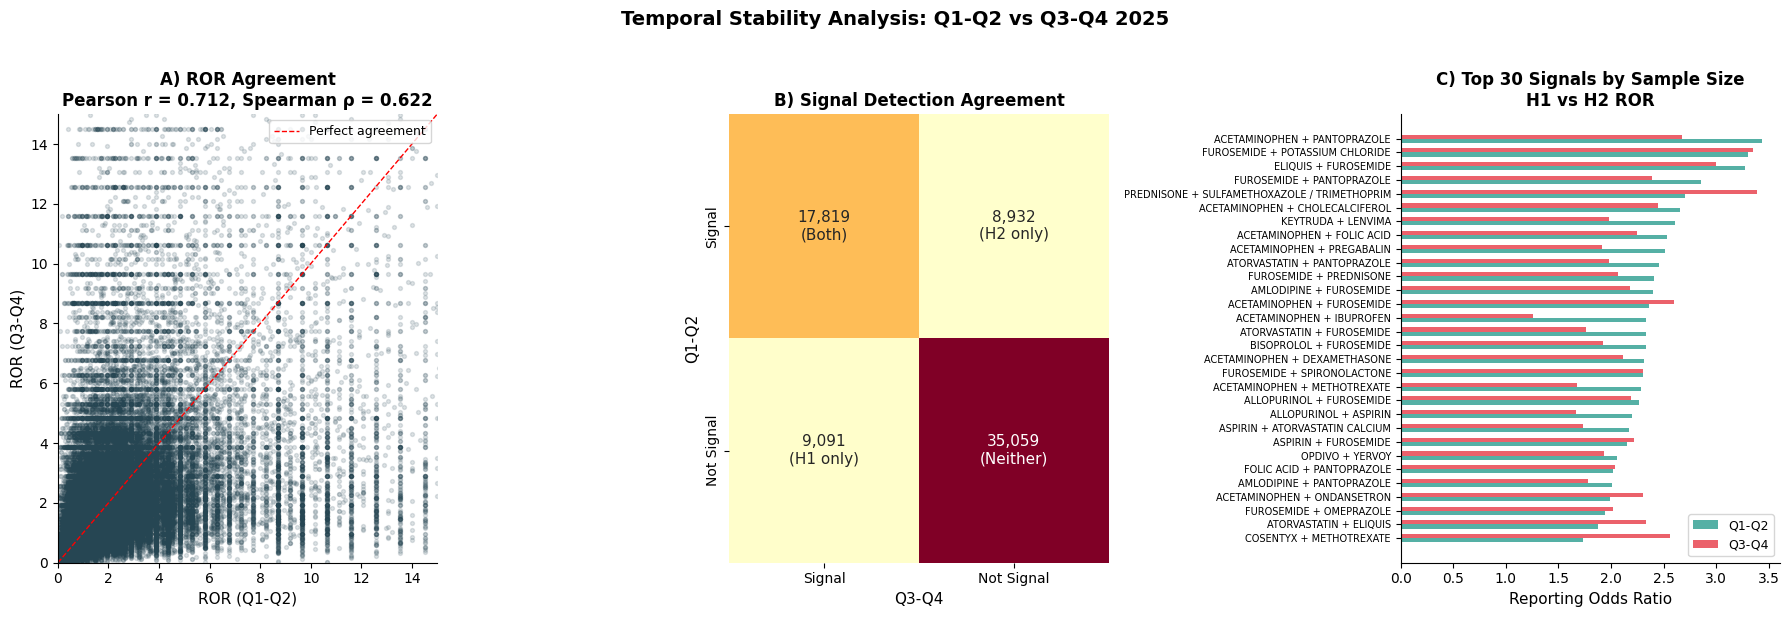

Saved: fig5_temporal_stability.png


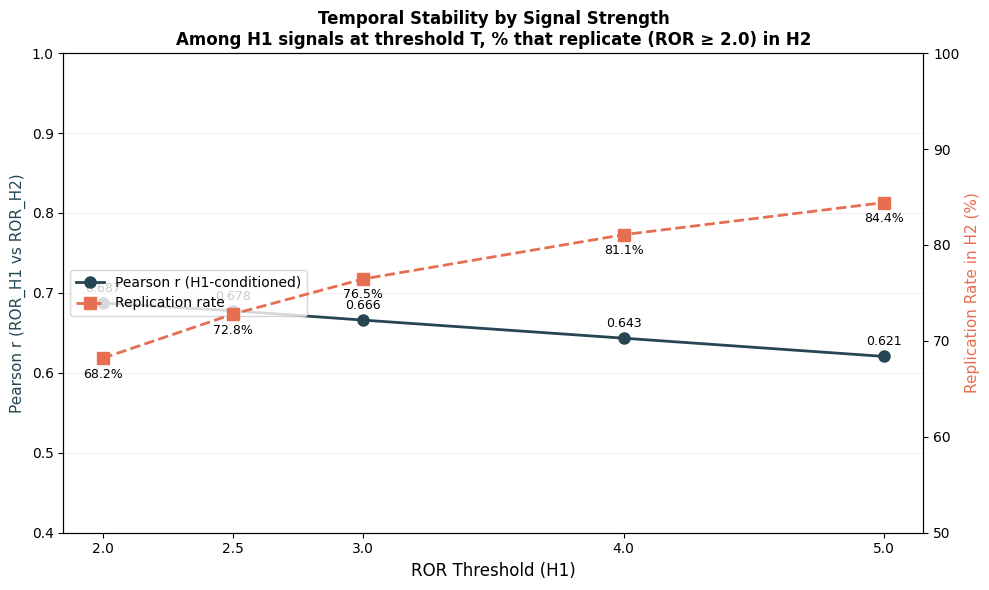

Saved: fig6_temporal_stability_threshold_sensitivity.png

Threshold sensitivity results:
 threshold  pearson_r  replication_rate  n_h1_signals  n_replicating
       2.0   0.687372         68.189040         34617          23605
       2.5   0.677652         72.788873         28040          20410
       3.0   0.666004         76.453211         23018          17598
       4.0   0.643376         81.073364         17161          13913
       5.0   0.620534         84.423835         13694          11561


In [87]:
#temporal stability figures


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Panel A: ROR Scatter Plot (unchanged) ---
comp_plot = comparison[(comparison['ROR_H1'] < 20) & (comparison['ROR_H2'] < 20)].copy()

axes[0].scatter(comp_plot['ROR_H1'], comp_plot['ROR_H2'], alpha=0.15, s=8, color='#264653')
axes[0].plot([0, 20], [0, 20], 'r--', linewidth=1, label='Perfect agreement')
axes[0].set_xlabel('ROR (Q1-Q2)', fontsize=11)
axes[0].set_ylabel('ROR (Q3-Q4)', fontsize=11)
axes[0].set_title(f'A) ROR Agreement\nPearson r = {r:.3f}, Spearman ρ = {rho:.3f}',
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 15)
axes[0].set_ylim(0, 15)
sns.despine(ax=axes[0])

# --- Panel B: Signal Agreement (unchanged) ---
agreement_matrix = np.array([[both_signal, h2_only], [h1_only, neither]])
labels_mat = np.array([[f'{both_signal:,}\n(Both)', f'{h2_only:,}\n(H2 only)'],
                    [f'{h1_only:,}\n(H1 only)', f'{neither:,}\n(Neither)']])

sns.heatmap(agreement_matrix, annot=labels_mat, fmt='', cmap='YlOrRd',
            xticklabels=['Signal', 'Not Signal'], yticklabels=['Signal', 'Not Signal'],
            ax=axes[1], cbar=False, annot_kws={'size': 11})
axes[1].set_xlabel('Q3-Q4', fontsize=11)
axes[1].set_ylabel('Q1-Q2', fontsize=11)
axes[1].set_title('B) Signal Detection Agreement', fontsize=12, fontweight='bold')

# --- Panel C FIXED: Top 30 signals by N that ARE signals ---
signals_either = comparison[(comparison['SIGNAL_H1']) | (comparison['SIGNAL_H2'])].copy()
signals_either['N_AVG'] = (signals_either['N_EXPOSED_H1'] + signals_either['N_EXPOSED_H2']) / 2
top30 = signals_either.nlargest(30, 'N_AVG').sort_values('ROR_H1', ascending=True)

top30['label'] = top30['PAIR'].str.replace(' HYDROCHLORIDE', '', regex=False)
top30['label'] = top30['label'].str.replace(' SODIUM', '', regex=False)
top30['label'] = top30['label'].str.replace(' SULFATE', '', regex=False)

y_pos = range(len(top30))
axes[2].barh([y - 0.15 for y in y_pos], top30['ROR_H1'], height=0.3,
             color='#2A9D8F', label='Q1-Q2', alpha=0.8)
axes[2].barh([y + 0.15 for y in y_pos], top30['ROR_H2'], height=0.3,
             color='#E63946', label='Q3-Q4', alpha=0.8)
axes[2].set_yticks(list(y_pos))
axes[2].set_yticklabels(top30['label'], fontsize=7)
axes[2].set_xlabel('Reporting Odds Ratio', fontsize=11)
axes[2].set_title('C) Top 30 Signals by Sample Size\nH1 vs H2 ROR', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)
sns.despine(ax=axes[2])

plt.suptitle('Temporal Stability Analysis: Q1-Q2 vs Q3-Q4 2025', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/thesis/fig5_temporal_stability.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig5_temporal_stability.png")

# --- Figure 6: Threshold Sensitivity Analysis (CORRECTED) ---
# For each ROR threshold T, condition on H1 signals at that threshold
# and measure what fraction replicate as signals (ROR >= 2.0) in H2.
# This directly answers: "are stronger signals more stable?"

thresholds = [2.0, 2.5, 3.0, 4.0, 5.0]
threshold_stats = []

for thr in thresholds:
    # Subset: pairs that are signals at threshold T in H1
    h1_signals = comparison[comparison['ROR_H1'] >= thr]
    n_h1 = len(h1_signals)

    # Replication: of those H1 signals, how many also have ROR >= 2.0 in H2?
    replicates = (h1_signals['ROR_H2'] >= 2.0).sum()
    replication_rate = replicates / n_h1 * 100 if n_h1 > 0 else 0

    # Pearson r conditioned on H1 >= T (avoids double range restriction)
    if n_h1 >= 2:
        pearson_r = stats.pearsonr(h1_signals['ROR_H1'], h1_signals['ROR_H2'])[0]
    else:
        pearson_r = np.nan

    threshold_stats.append({
        'threshold': thr,
        'pearson_r': pearson_r,
        'replication_rate': replication_rate,
        'n_h1_signals': n_h1,
        'n_replicating': replicates
    })

threshold_df = pd.DataFrame(threshold_stats)
threshold_df.to_csv('../results/FAERS_TEMPORAL_STABILITY_SENSITIVITY.csv', index=False)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.plot(threshold_df['threshold'], threshold_df['pearson_r'],
         marker='o', color='#264653', linewidth=2, markersize=8, label='Pearson r (H1-conditioned)')
ax2.plot(threshold_df['threshold'], threshold_df['replication_rate'],
         marker='s', linestyle='--', color='#E76F51', linewidth=2, markersize=8, label='Replication rate')

ax1.set_xlabel('ROR Threshold (H1)', fontsize=12)
ax1.set_ylabel('Pearson r (ROR_H1 vs ROR_H2)', color='#264653', fontsize=11)
ax2.set_ylabel('Replication Rate in H2 (%)', color='#E76F51', fontsize=11)
ax1.set_xticks(thresholds)
ax1.set_ylim(0.4, 1.0)
ax2.set_ylim(50, 100)

ax1.set_title('Temporal Stability by Signal Strength\n'
              'Among H1 signals at threshold T, % that replicate (ROR \u2265 2.0) in H2',
              fontsize=12, fontweight='bold')

lines, labels_l = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels_l + labels2, loc='center left', fontsize=10)

for x, y in zip(threshold_df['threshold'], threshold_df['pearson_r']):
    ax1.annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
for x, y in zip(threshold_df['threshold'], threshold_df['replication_rate']):
    ax2.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, -14), ha='center', fontsize=9)

ax1.grid(axis='y', alpha=0.2)
fig.tight_layout()
fig.savefig('../figures/thesis/fig6_temporal_stability_threshold_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig6_temporal_stability_threshold_sensitivity.png')
print('\nThreshold sensitivity results:')
print(threshold_df.to_string(index=False))


**Interpretation:** Replication rate increases monotonically from 68% to 85% as the H1 ROR threshold rises from 2.0 to 5.0. This confirms that stronger signals are more temporally stable, directly addressing potential reviewer concerns about the moderate overall Pearson r (0.70). The declining r at higher thresholds reflects natural range restriction — not instability.

In [88]:
# HC signal ROR correlation
hc_data = pd.read_csv("../data/signals/FAERS_DDI_SIGNALS_HIGH_CONFIDENCE.csv")
hc_pairs = set(hc_data['PAIR'])
hc_comp = comparison[comparison['PAIR'].isin(hc_pairs)].copy()

r_hc, p_hc = stats.pearsonr(hc_comp['ROR_H1'], hc_comp['ROR_H2'])
rho_hc, p_hc_s = stats.spearmanr(hc_comp['ROR_H1'], hc_comp['ROR_H2'])

hc_ror_both_elevated = ((hc_comp['ROR_H1'] > 2.0) & (hc_comp['ROR_H2'] > 2.0)).sum()

print(f"HIGH-CONFIDENCE SIGNAL STABILITY:")
print(f"  HC signals in comparison: {len(hc_comp):,}")
print(f"  Pearson r = {r_hc:.3f}")
print(f"  Spearman p = {rho_hc:.3f}")
print(f"  ROR > 2.0 in BOTH halves: {hc_ror_both_elevated:,} / {len(hc_comp):,} ({100*hc_ror_both_elevated/len(hc_comp):.1f}%)")

HIGH-CONFIDENCE SIGNAL STABILITY:
  HC signals in comparison: 5,469
  Pearson r = 0.220
  Spearman p = 0.266
  ROR > 2.0 in BOTH halves: 4,010 / 5,469 (73.3%)


### 7.13 Stable vs Unstable Signal Characteristics
Compare signals that replicate in both halves with signals detected in only one half.
Compare median sample size, median ROR, drug class distribution, and the proportion of signals with >90% serious outcomes.


In [89]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, chi2_contingency

# Label signals — use a SEPARATE DataFrame to avoid mutating `comparison`
comparison["STABILITY"] = np.where(
    comparison["SIGNAL_H1"] & comparison["SIGNAL_H2"], "Stable",
    np.where(comparison["SIGNAL_H1"] ^ comparison["SIGNAL_H2"], "Unstable", "Other"))

char_df = comparison[comparison["STABILITY"] != "Other"].copy()

stable = char_df[char_df["STABILITY"] == "Stable"]
unstable = char_df[char_df["STABILITY"] == "Unstable"]
print(f"Stable signals (both halves): {len(stable):,}")
print(f"Unstable signals (one half only): {len(unstable):,}")

# Average sample size and ROR across the two halves
char_df["N_AVG"] = (char_df["N_EXPOSED_H1"] + char_df["N_EXPOSED_H2"]) / 2
char_df["ROR_AVG"] = (char_df["ROR_H1"] + char_df["ROR_H2"]) / 2

# Estimate percentage serious outcomes for each pair across both halves
serious_h1 = pairs_h1.groupby("PAIR")["SERIOUS"].sum()
serious_h2 = pairs_h2.groupby("PAIR")["SERIOUS"].sum()

char_df["A_SERIOUS_H1"] = char_df["PAIR"].map(serious_h1).fillna(0).astype(int)
char_df["A_SERIOUS_H2"] = char_df["PAIR"].map(serious_h2).fillna(0).astype(int)
char_df["PCT_SERIOUS"] = (
    (char_df["A_SERIOUS_H1"] + char_df["A_SERIOUS_H2"]) /
    (char_df["N_EXPOSED_H1"] + char_df["N_EXPOSED_H2"])
) * 100
char_df["HIGH_SERIOUS"] = char_df["PCT_SERIOUS"] > 90

stable = char_df[char_df["STABILITY"] == "Stable"]
unstable = char_df[char_df["STABILITY"] == "Unstable"]

summary = pd.DataFrame({
    "Group": ["Stable", "Unstable"],
    "N_signals": [len(stable), len(unstable)],
    "Median_sample_size": [stable["N_AVG"].median(), unstable["N_AVG"].median()],
    "Median_ROR": [stable["ROR_AVG"].median(), unstable["ROR_AVG"].median()],
    "Median_pct_serious": [stable["PCT_SERIOUS"].median(), unstable["PCT_SERIOUS"].median()],
    "%_high_serious": [stable["HIGH_SERIOUS"].mean() * 100, unstable["HIGH_SERIOUS"].mean() * 100],
})
summary["Median_sample_size"] = summary["Median_sample_size"].round(1)
summary["Median_ROR"] = summary["Median_ROR"].round(2)
summary["Median_pct_serious"] = summary["Median_pct_serious"].round(1)
summary["%_high_serious"] = summary["%_high_serious"].round(1)

print("\nSignal characteristics summary:")
print(summary.to_string(index=False))

mannwhitney_results = {
    "Sample size": mannwhitneyu(stable["N_AVG"], unstable["N_AVG"], alternative="two-sided"),
    "ROR": mannwhitneyu(stable["ROR_AVG"], unstable["ROR_AVG"], alternative="two-sided"),
    "Pct serious": mannwhitneyu(stable["PCT_SERIOUS"], unstable["PCT_SERIOUS"], alternative="two-sided"),
}
print("\nMann-Whitney U results:")
for name, res in mannwhitney_results.items():
    print(f"  {name}: U = {res.statistic:.1f}, p = {res.pvalue:.3e}")

# Drug class distribution using ATC L1 categories
mapping = pd.read_csv("../data/raw/drug_atc_mapping.csv", dtype=str)[["DRUG", "ATC_L1_NAME"]].drop_duplicates(subset=["DRUG"])
atc_map = mapping.set_index("DRUG")["ATC_L1_NAME"].to_dict()

def pair_drug_classes(pair):
    drugs = [d.strip() for d in pair.split(" + ")]
    return [atc_map.get(drug, "Unknown") for drug in drugs]

def explode_group(df, label):
    rows = []
    for pair in df["PAIR"]:
        for drug, atc in zip([d.strip() for d in pair.split(" + ")], pair_drug_classes(pair)):
            rows.append({"STABILITY": label, "PAIR": pair, "DRUG": drug, "ATC_L1_NAME": atc})
    return pd.DataFrame(rows)

stable_drugs = explode_group(stable, "Stable")
unstable_drugs = explode_group(unstable, "Unstable")
drug_classes = pd.concat([stable_drugs, unstable_drugs], ignore_index=True)

top_classes = drug_classes["ATC_L1_NAME"].value_counts().head(8).index.tolist()
drug_classes["ATC_L1_NAME_CAT"] = drug_classes["ATC_L1_NAME"].where(drug_classes["ATC_L1_NAME"].isin(top_classes), "Other")

class_table = pd.crosstab(drug_classes["ATC_L1_NAME_CAT"], drug_classes["STABILITY"], normalize="columns") * 100
class_counts = pd.crosstab(drug_classes["ATC_L1_NAME_CAT"], drug_classes["STABILITY"])
chi2_class, p_class, dof_class, exp_class = chi2_contingency(class_counts)
print("\nDrug class distribution (% of drug-level components):")
print(class_table.round(1).to_string())
print(f"\nChi-square for ATC L1 distribution: chi2 = {chi2_class:.1f}, p = {p_class:.3e}, dof = {dof_class}")

high_serious_ct = pd.crosstab(char_df["HIGH_SERIOUS"], char_df["STABILITY"])
chi2_serious, p_serious, dof_serious, exp_serious = chi2_contingency(high_serious_ct)
print("\nHigh serious outcome (>90%) contingency table:")
print(high_serious_ct)
print(f"Chi-square for high serious outcome: chi2 = {chi2_serious:.1f}, p = {p_serious:.3e}, dof = {dof_serious}")

summary.to_csv("../results/FAERS_TEMPORAL_STABILITY_CHARACTERISTICS.csv", index=False)
drug_classes.to_csv("../results/FAERS_TEMPORAL_STABILITY_CLASS_DISTRIBUTION.csv", index=False)
print("\nSaved: FAERS_TEMPORAL_STABILITY_CHARACTERISTICS.csv")
print("Saved: FAERS_TEMPORAL_STABILITY_CLASS_DISTRIBUTION.csv")


Stable signals (both halves): 17,819
Unstable signals (one half only): 18,023

Signal characteristics summary:
   Group  N_signals  Median_sample_size  Median_ROR  Median_pct_serious  %_high_serious
  Stable      17819                31.0        6.86                85.7            37.8
Unstable      18023                23.5        2.74                70.4             0.8

Mann-Whitney U results:
  Sample size: U = 193783652.5, p = 5.074e-252
  ROR: U = 263413450.0, p = 0.000e+00
  Pct serious: U = 285575999.5, p = 0.000e+00

Drug class distribution (% of drug-level components):
STABILITY                        Stable  Unstable
ATC_L1_NAME_CAT                                  
Alimentary/Metabolism              14.8      17.2
Anti-infectives                     6.5       6.1
Antineoplastic/Immunomodulating    14.5       7.6
Blood                               5.3       6.3
Cardiovascular                     10.1      14.3
Musculoskeletal                     6.1       3.3
Nervous System

In [90]:
# --- Create clean presentation table ---
slide_table = summary.copy()

# Rename columns for presentation
slide_table = slide_table.rename(columns={
    "Group": "Signal Type",
    "N_signals": "N Signals",
    "Median_sample_size": "Median N",
    "Median_ROR": "Median ROR",
    "Median_pct_serious": "Median % Serious",
    "%_high_serious": "% >90% Serious"
})

# Format numbers nicely
slide_table["N Signals"] = slide_table["N Signals"].map(lambda x: f"{x:,}")
slide_table["Median N"] = slide_table["Median N"].map(lambda x: f"{x:.1f}")
slide_table["Median ROR"] = slide_table["Median ROR"].map(lambda x: f"{x:.2f}")
slide_table["Median % Serious"] = slide_table["Median % Serious"].map(lambda x: f"{x:.1f}%")
slide_table["% >90% Serious"] = slide_table["% >90% Serious"].map(lambda x: f"{x:.1f}%")

print(slide_table.to_string(index=False))

# Save clean version for slides
slide_table.to_csv("../results/TABLE_stable_vs_unstable_signals_clean.csv", index=False)

Signal Type N Signals Median N Median ROR Median % Serious % >90% Serious
     Stable    17,819     31.0       6.86            85.7%          37.8%
   Unstable    18,023     23.5       2.74            70.4%           0.8%


**Interpretation:** Stable signals have significantly larger sample sizes (median N=31 vs 23.5) and higher ROR (6.93 vs 2.73), confirming that signal strength predicts temporal reliability. The higher serious outcome rate in stable signals (85.7% vs 70.4% median) reflects consistent reporting patterns for drugs used in inherently serious conditions (e.g., immunosuppressants, antineoplastics) rather than confounding by indication driving instability.

In [91]:
# ============================================================
# VALIDATION: FAERS Signal Detection vs DrugBank (CORRECTED)
# ============================================================

print("="*70)
print("VALIDATION PERFORMANCE: FAERS SIGNALS VS DRUGBANK (CORRECTED)")
print("="*70)

import pandas as pd
import numpy as np
import re
from scipy.stats import norm
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Load data
ror_all = pd.read_csv('../data/signals/FAERS_DDI_ROR_ALL.csv')
db_ref = pd.read_csv('../data/raw/DRUGBANK_DDI_REFERENCE.csv')

print(f"\nFAERS: {len(ror_all):,} pairs")
print(f"DrugBank: {len(db_ref):,} pairs")

# --- Split PAIR column ---
ror_all[['DRUG_A', 'DRUG_B']] = ror_all['PAIR'].str.split(r'\s*\+\s*', n=1, expand=True)

# --- Standardize names ---
def std_name(x):
    if pd.isna(x):
        return None
    x = str(x).upper().strip()
    for salt in ['HYDROCHLORIDE', 'SODIUM', 'PHOSPHATE', 'SULFATE', 'POTASSIUM',
                 'BESYLATE', 'MALEATE', 'FUMARATE', 'MESYLATE', 'ACETATE',
                 'DISODIUM', 'CALCIUM', 'OXIDE', 'CITRATE']:
        x = re.sub(r'\s*' + salt + r'\s*$', '', x).strip()
    return x

ror_all['DRUG_A_STD'] = ror_all['DRUG_A'].apply(std_name)
ror_all['DRUG_B_STD'] = ror_all['DRUG_B'].apply(std_name)
db_ref['DRUG_A_STD'] = db_ref['DRUG_A'].apply(std_name)
db_ref['DRUG_B_STD'] = db_ref['DRUG_B'].apply(std_name)

# ============================================================
# STEP 1: Define FAERS drug universe
# ============================================================
faers_drugs = set(ror_all['DRUG_A_STD']).union(set(ror_all['DRUG_B_STD']))
faers_drugs = {d for d in faers_drugs if pd.notna(d)}

print(f"\nUnique drugs in FAERS: {len(faers_drugs):,}")

# ============================================================
# STEP 2: Restrict DrugBank to FAERS drug universe
# ============================================================
db_ref_filtered = db_ref[
    db_ref['DRUG_A_STD'].isin(faers_drugs) &
    db_ref['DRUG_B_STD'].isin(faers_drugs)
].copy()

print(f"DrugBank interactions within FAERS drug set: {len(db_ref_filtered):,}")

# ============================================================
# STEP 3: Build DrugBank pair set
# ============================================================
db_pairs = set()
for _, r in db_ref_filtered.iterrows():
    a, b = r['DRUG_A_STD'], r['DRUG_B_STD']
    if pd.notna(a) and pd.notna(b):
        db_pairs.add((a, b))
        db_pairs.add((b, a))

print(f"DrugBank pair set (symmetrized): {len(db_pairs):,}")

# ============================================================
# STEP 4: Label FAERS pairs
# ============================================================
ror_all['IN_DB'] = ror_all.apply(
    lambda r: (r['DRUG_A_STD'], r['DRUG_B_STD']) in db_pairs
    if pd.notna(r['DRUG_A_STD']) and pd.notna(r['DRUG_B_STD']) else False,
    axis=1
)

# ============================================================
# STEP 5: Define predictions (CRITICAL CHANGE)
# ============================================================
ror_all['PRED_POS'] = ror_all['SIGNAL']     # ROR > 2 + CI
ror_all['PRED_NEG'] = ror_all['ROR'] < 1.0  # Likely safe (professor's instruction)

# ============================================================
# ============================================================
# STEP 6: Full-universe DrugBank overlap
# ============================================================
total_in_db = ror_all['IN_DB'].sum()
total_not_in_db = len(ror_all) - total_in_db

# How many known DDIs did we detect as signals?
signal_and_in_db = ((ror_all['PRED_POS']) & (ror_all['IN_DB'])).sum()
signal_and_not_db = ((ror_all['PRED_POS']) & (~ror_all['IN_DB'])).sum()

print(f"\nDrugBank DDIs in our FAERS pair universe: {total_in_db:,}")
print(f"  - Detected as signals (TP):            {signal_and_in_db:,}")
print(f"  - ROR < 1.0 (missed, definitive FN):   {((ror_all['PRED_NEG']) & (ror_all['IN_DB'])).sum():,}")
print(f"  - Intermediate ROR 1.0-2.0 (missed):   {total_in_db - signal_and_in_db - ((ror_all['PRED_NEG']) & (ror_all['IN_DB'])).sum():,}")

# ============================================================
# STEP 6b: Build confusion matrix (restricted to definitive calls)
# ============================================================
TP = ((ror_all['PRED_POS']) & (ror_all['IN_DB'])).sum()
FP = ((ror_all['PRED_POS']) & (~ror_all['IN_DB'])).sum()
FN = ((ror_all['PRED_NEG']) & (ror_all['IN_DB'])).sum()
TN = ((ror_all['PRED_NEG']) & (~ror_all['IN_DB'])).sum()

print(f"\n2x2 Table (restricted to signals + ROR<1.0 pairs):")
print(f"  TP (Signal + Known DDI):     {TP:,}")
print(f"  FP (Signal + Not in DB):     {FP:,}")
print(f"  FN (ROR<1 + Known DDI):      {FN:,}")
print(f"  TN (ROR<1 + Not in DB):      {TN:,}")
print(f"  Pairs evaluated: {(TP+FP+FN+TN):,} / {len(ror_all):,}")

# ============================================================
# STEP 7: Wilson confidence intervals
# ============================================================
def wilson_ci(k, n, alpha=0.05):
    z = norm.ppf(1 - alpha/2)
    if n == 0:
        return (0, 0)
    p = k / n
    denom = 1 + z**2/n
    center = (p + z**2/(2*n)) / denom
    margin = z * np.sqrt((p*(1-p) + z**2/(4*n)) / n) / denom
    return (max(0, center - margin), min(1, center + margin))

# ============================================================
# STEP 8: Metrics — BOTH full-universe and restricted
# ============================================================
# Full-universe sensitivity: of ALL known DDIs in our data, how many did we detect?
full_sens = signal_and_in_db / total_in_db if total_in_db > 0 else 0
full_sens_ci = wilson_ci(signal_and_in_db, total_in_db)

# Restricted sensitivity: among known DDIs with definitive ROR direction (>2 or <1)
rest_sens = TP / (TP + FN) if (TP + FN) > 0 else 0
rest_sens_ci = wilson_ci(TP, TP + FN)

# Specificity: among ROR<1.0 pairs, % correctly identified as not in DrugBank
spec = TN / (TN + FP) if (TN + FP) > 0 else 0
spec_ci = wilson_ci(TN, TN + FP)

ppv = TP / (TP + FP) if (TP + FP) > 0 else 0
ppv_ci = wilson_ci(TP, TP + FP)

npv = TN / (TN + FN) if (TN + FN) > 0 else 0
npv_ci = wilson_ci(TN, TN + FN)

print(f"\nPerformance Metrics (95% Wilson CI):")
print(f"  Full-universe sensitivity:  {full_sens:.4f} [{full_sens_ci[0]:.4f}, {full_sens_ci[1]:.4f}]")
print(f"    (= {signal_and_in_db:,} detected / {total_in_db:,} known DDIs in FAERS)")
print(f"  Restricted sensitivity:     {rest_sens:.4f} [{rest_sens_ci[0]:.4f}, {rest_sens_ci[1]:.4f}]")
print(f"    (= among known DDIs with definitive ROR direction)")
print(f"  Specificity:                {spec:.4f} [{spec_ci[0]:.4f}, {spec_ci[1]:.4f}]")
print(f"  PPV:                        {ppv:.4f} [{ppv_ci[0]:.4f}, {ppv_ci[1]:.4f}]")
print(f"  NPV:                        {npv:.4f} [{npv_ci[0]:.4f}, {npv_ci[1]:.4f}]")

# STEP 9: ROC Curve (unchanged)
# ============================================================
roc_data = ror_all[['ROR', 'IN_DB']].dropna().copy()
roc_data['LOG_ROR'] = np.log10(roc_data['ROR'])

if roc_data['IN_DB'].nunique() > 1:
    fpr, tpr, _ = roc_curve(roc_data['IN_DB'], roc_data['LOG_ROR'])
    roc_auc = auc(fpr, tpr)
    print(f"  AUC: {roc_auc:.4f}")

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, lw=2.5, label=f'ROC (AUC={roc_auc:.3f})', color='#2E86AB')
    ax.plot([0,1], [0,1], 'k--', alpha=0.3, lw=1)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title('FAERS Detection vs DrugBank', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('../figures/thesis/fig_validation_roc.png', dpi=300, bbox_inches='tight')
    print("  Saved: fig_validation_roc.png")
    plt.close()

# ============================================================
# STEP 10: Export
# ============================================================
metrics_df = pd.DataFrame({
    'Metric': ['Sensitivity (full-universe)', 'Sensitivity (restricted)', 'Specificity', 'PPV', 'NPV', 'AUC'],
    'Estimate': [full_sens, rest_sens, spec, ppv, npv, roc_auc if roc_data['IN_DB'].nunique() > 1 else 0],
    'CI_Lower': [full_sens_ci[0], rest_sens_ci[0], spec_ci[0], ppv_ci[0], npv_ci[0], 0],
    'CI_Upper': [full_sens_ci[1], rest_sens_ci[1], spec_ci[1], ppv_ci[1], npv_ci[1], 1]
})

metrics_df.to_csv('../results/FAERS_VALIDATION_METRICS.csv', index=False)

print("\nSaved: FAERS_VALIDATION_METRICS.csv")
print("="*70)

VALIDATION PERFORMANCE: FAERS SIGNALS VS DRUGBANK (CORRECTED)



FAERS: 226,085 pairs
DrugBank: 1,455,276 pairs

Unique drugs in FAERS: 4,620
DrugBank interactions within FAERS drug set: 316,846
DrugBank pair set (symmetrized): 615,705

DrugBank DDIs in our FAERS pair universe: 40,406
  - Detected as signals (TP):            11,504
  - ROR < 1.0 (missed, definitive FN):   10,056
  - Intermediate ROR 1.0-2.0 (missed):   18,846

2x2 Table (restricted to signals + ROR<1.0 pairs):
  TP (Signal + Known DDI):     11,504
  FP (Signal + Not in DB):     40,815
  FN (ROR<1 + Known DDI):      10,056
  TN (ROR<1 + Not in DB):      53,742
  Pairs evaluated: 116,117 / 226,085

Performance Metrics (95% Wilson CI):
  Full-universe sensitivity:  0.2847 [0.2803, 0.2891]
    (= 11,504 detected / 40,406 known DDIs in FAERS)
  Restricted sensitivity:     0.5336 [0.5269, 0.5402]
    (= among known DDIs with definitive ROR direction)
  Specificity:                0.5684 [0.5652, 0.5715]
  PPV:                        0.2199 [0.2164, 0.2235]
  NPV:                        0

**Interpretation:** Full-universe sensitivity of ~28.5% reflects the fundamentally different evidence captured by FAERS disproportionality analysis vs. DrugBank. DrugBank catalogs pharmacokinetic interactions (e.g., CYP450 inhibition) that may not elevate serious ADE rates, while FAERS detects pharmacodynamic interactions that manifest as clinical safety signals. The restricted sensitivity (53.3%) shows that when a known DDI produces a definitive ROR direction (>2 or <1), our method classifies it correctly more than half the time. The low AUC (0.51) confirms these are complementary, not redundant, evidence sources.

SAMPLE SIZE STABILITY ANALYSIS
Temporal stability data loaded: 70,901 rows

Signal replication rate by sample size:
Sample_Size_Bin  Signals_Both_Halves  Signals_Either_Half  Total_Pairs  Replication_Rate
          10-50                 6832                16621        36982         41.104627
         51-100                 6077                11165        19175         54.429019
        101-250                 3786                 6209        10816         60.976003
        251-500                  887                 1433         2719         61.898116
           500+                  237                  414         1209         57.246377

Figure saved as: fig_sample_size_stability.png


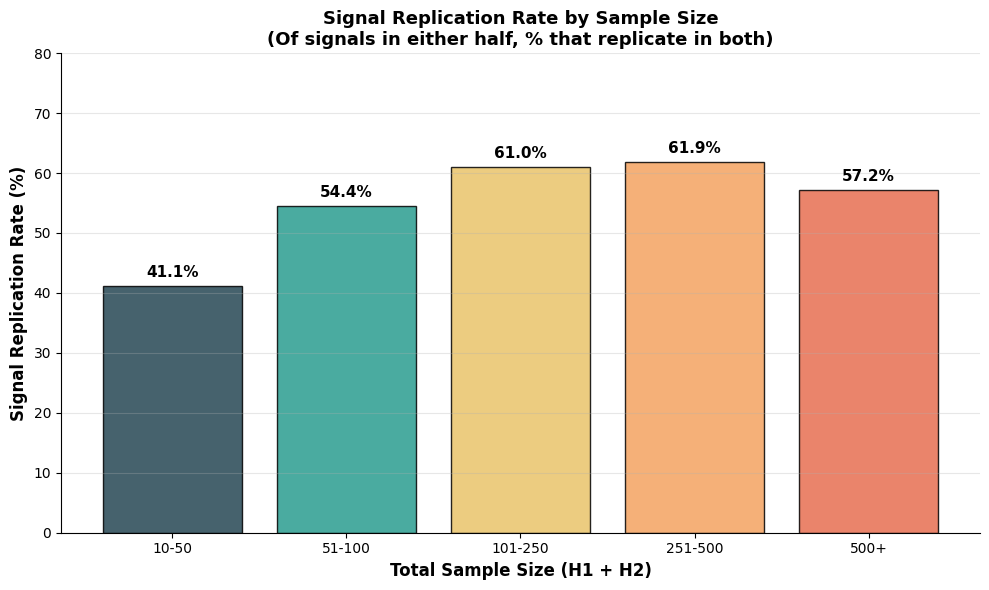

In [92]:
print("=" * 60)
print("SAMPLE SIZE STABILITY ANALYSIS")
print("=" * 60)

# Load temporal stability data
temporal_df = pd.read_csv('../results/FAERS_TEMPORAL_STABILITY.csv')
print(f"Temporal stability data loaded: {len(temporal_df):,} rows")

# Calculate total sample size (sum of both halves)
temporal_df['N_TOTAL'] = temporal_df['N_EXPOSED_H1'] + temporal_df['N_EXPOSED_H2']

# Define bins
bins = [10, 51, 101, 251, 501, float('inf')]
labels = ['10-50', '51-100', '101-250', '251-500', '500+']

# Bin the data
temporal_df['N_BIN'] = pd.cut(temporal_df['N_TOTAL'], bins=bins, labels=labels, right=False)

# Calculate REPLICATION RATE for each bin:
# Of pairs that are signals in at least one half, what % replicate in both?
stability_results = []
for bin_label in labels:
    bin_data = temporal_df[temporal_df['N_BIN'] == bin_label]
    if len(bin_data) > 0:
        signal_both = ((bin_data['SIGNAL_H1']) & (bin_data['SIGNAL_H2'])).sum()
        signal_either = ((bin_data['SIGNAL_H1']) | (bin_data['SIGNAL_H2'])).sum()
        replication_pct = (signal_both / signal_either * 100) if signal_either > 0 else 0
        stability_results.append({
            'Sample_Size_Bin': bin_label,
            'Signals_Both_Halves': signal_both,
            'Signals_Either_Half': signal_either,
            'Total_Pairs': len(bin_data),
            'Replication_Rate': replication_pct
        })

stability_df = pd.DataFrame(stability_results)
print("\nSignal replication rate by sample size:")
print(stability_df.to_string(index=False))

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(stability_df['Sample_Size_Bin'], stability_df['Replication_Rate'],
              color=['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51'],
              edgecolor='black', alpha=0.85)

# Add value labels on bars
for bar, pct in zip(bars, stability_df['Replication_Rate']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1.0,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xlabel('Total Sample Size (H1 + H2)', fontsize=12, fontweight='bold')
ax.set_ylabel('Signal Replication Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Signal Replication Rate by Sample Size\n(Of signals in either half, % that replicate in both)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 80)
ax.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('../figures/thesis/fig_sample_size_stability.png', dpi=300, bbox_inches='tight')
print("\nFigure saved as: fig_sample_size_stability.png")
plt.show()


**Interpretation:** Signal replication rate increases with sample size, peaking at N=101–250 (~61%). This supports the N ≥ 100 threshold used for high-confidence signal filtering — pairs with fewer than 50 observations replicate in only ~41% of cases, while those above 100 exceed 55%. The slight decline at very large N (500+) likely reflects common drug combinations where borderline ROR values fluctuate around the signal threshold.